# Fish Disparity

In [3]:
#!pip install opencv-contrib-python

In [1]:
import numpy as np
import cv2
import glob


import os
from pathlib import Path

import sys
from matplotlib import pyplot as plt
%matplotlib inline

### Import calib/rect parameters

In [2]:
cv_file = cv2.FileStorage("improved_params2.xml", cv2.FILE_STORAGE_READ)
Left_Stereo_Map_x = cv_file.getNode("Left_Stereo_Map_x").mat()
Left_Stereo_Map_y = cv_file.getNode("Left_Stereo_Map_y").mat()
Right_Stereo_Map_x = cv_file.getNode("Right_Stereo_Map_x").mat()
Right_Stereo_Map_y = cv_file.getNode("Right_Stereo_Map_y").mat()

### Calibration Check

In [4]:
left_image = cv2.imread('./up/image1_u.jpg')
right_image = cv2.imread('./down/image1_d.jpg')
height, width = right_image.shape[:2]

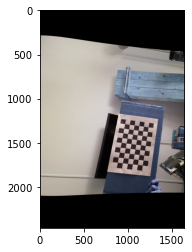

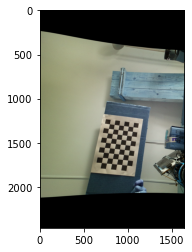

In [5]:
Left_nice= cv2.remap(left_image,Left_Stereo_Map_x,Left_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
Right_nice= cv2.remap(right_image,Right_Stereo_Map_x,Right_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
plt.imshow(Left_nice)
plt.show()
plt.imshow(Right_nice)
plt.show()

### Disparity map 
to do : optimize params (window size , min/max disparities) ?

In [22]:
def depth_map(imgL, imgR):
    """ Depth map calculation. Works with SGBM and WLS. Need rectified images, returns depth map ( left to right disparity ) """
    # SGBM Parameters -----------------
    window_size= 5  # wsize default 3; 5; 7 for SGBM reduced size image; 15 for SGBM full size image (1300px and above); 5 Works nicely

    left_matcher = cv2.StereoSGBM_create(
        minDisparity=1, # Andrea changed from -1
        numDisparities=5*16,  # max_disp has to be dividable by 16 f. E. HH 192, 256
        blockSize=window_size,
        P1=8 * 3 * window_size,
        # wsize default 3; 5; 7 for SGBM reduced size image; 15 for SGBM full size image (1300px and above); 5 Works nicely
        P2=32 * 3 * window_size,
        disp12MaxDiff=12,
        uniquenessRatio=10,
        speckleWindowSize=50,
        speckleRange=32,
        preFilterCap=63,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )
    right_matcher = cv2.ximgproc.createRightMatcher(left_matcher)
    # FILTER Parameters
    lmbda = 80000
    sigma = 1.3
    visual_multiplier = 6

    wls_filter = cv2.ximgproc.createDisparityWLSFilter(matcher_left=left_matcher)
    wls_filter.setLambda(lmbda)

    wls_filter.setSigmaColor(sigma)
    displ = left_matcher.compute(imgL, imgR)  # .astype(np.float32)/16
    dispr = right_matcher.compute(imgR, imgL)  # .astype(np.float32)/16
    displ = np.int16(displ)
    dispr = np.int16(dispr)
    filteredImg = wls_filter.filter(displ, imgL, None, dispr)  # important to put "imgL" here!!!

    filteredImg = cv2.normalize(src=filteredImg, dst=filteredImg, beta=0, alpha=255, norm_type=cv2.NORM_MINMAX);
    filteredImg = np.uint8(filteredImg)

    return filteredImg

In [7]:
gray_left = cv2.cvtColor(Left_nice, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(Right_nice, cv2.COLOR_BGR2GRAY)
disparity_image = depth_map(gray_left, gray_right)

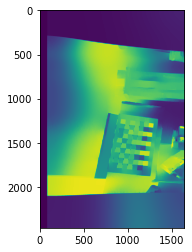

In [8]:
plt.imshow(disparity_image)
plt.show()

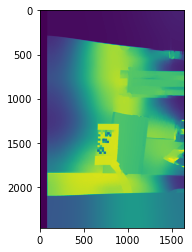

In [9]:
left_image = cv2.imread('./up/image10_u.jpg')
right_image = cv2.imread('./down/image10_d.jpg')
Left_nice= cv2.remap(left_image,Left_Stereo_Map_x,Left_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
Right_nice= cv2.remap(right_image,Right_Stereo_Map_x,Right_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
gray_left = cv2.cvtColor(Left_nice, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(Right_nice, cv2.COLOR_BGR2GRAY)
disparity_image = depth_map(gray_left, gray_right)
plt.imshow(disparity_image)

# Fish

In [23]:
def disparity_img(left_img_path : str , right_img_path : str):
    ''' returns disparity after rectifying image'''
    left_image = cv2.imread(left_img_path)
    right_image = cv2.imread(right_img_path)
    Left_nice= cv2.remap(left_image,Left_Stereo_Map_x,Left_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
    Right_nice= cv2.remap(right_image,Right_Stereo_Map_x,Right_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
    gray_left = cv2.cvtColor(Left_nice, cv2.COLOR_RGB2GRAY)
    gray_right = cv2.cvtColor(Right_nice, cv2.COLOR_RGB2GRAY)    
    #gray_left = cv2.cvtColor(Left_nice, cv2.COLOR_BGR2GRAY)
    #gray_right = cv2.cvtColor(Right_nice, cv2.COLOR_BGR2GRreturny_image = depth_map(gray_leftght)ty_image)
    return depth_map(gray_left, gray_right)

In [24]:
# fish location
fish_up = glob.glob('./fup/*.jpg')
fish_down = glob.glob('./fdown/*.jpg')   
fish_up = list(fish_up)
fish_down = list(fish_down)

In [18]:
i = 2
f1 , f2 = fish_up[i] , fish_down[i]

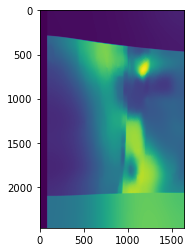

In [26]:
plt.imshow(disparity_img(f1 , f2))

In [20]:
from PIL import Image

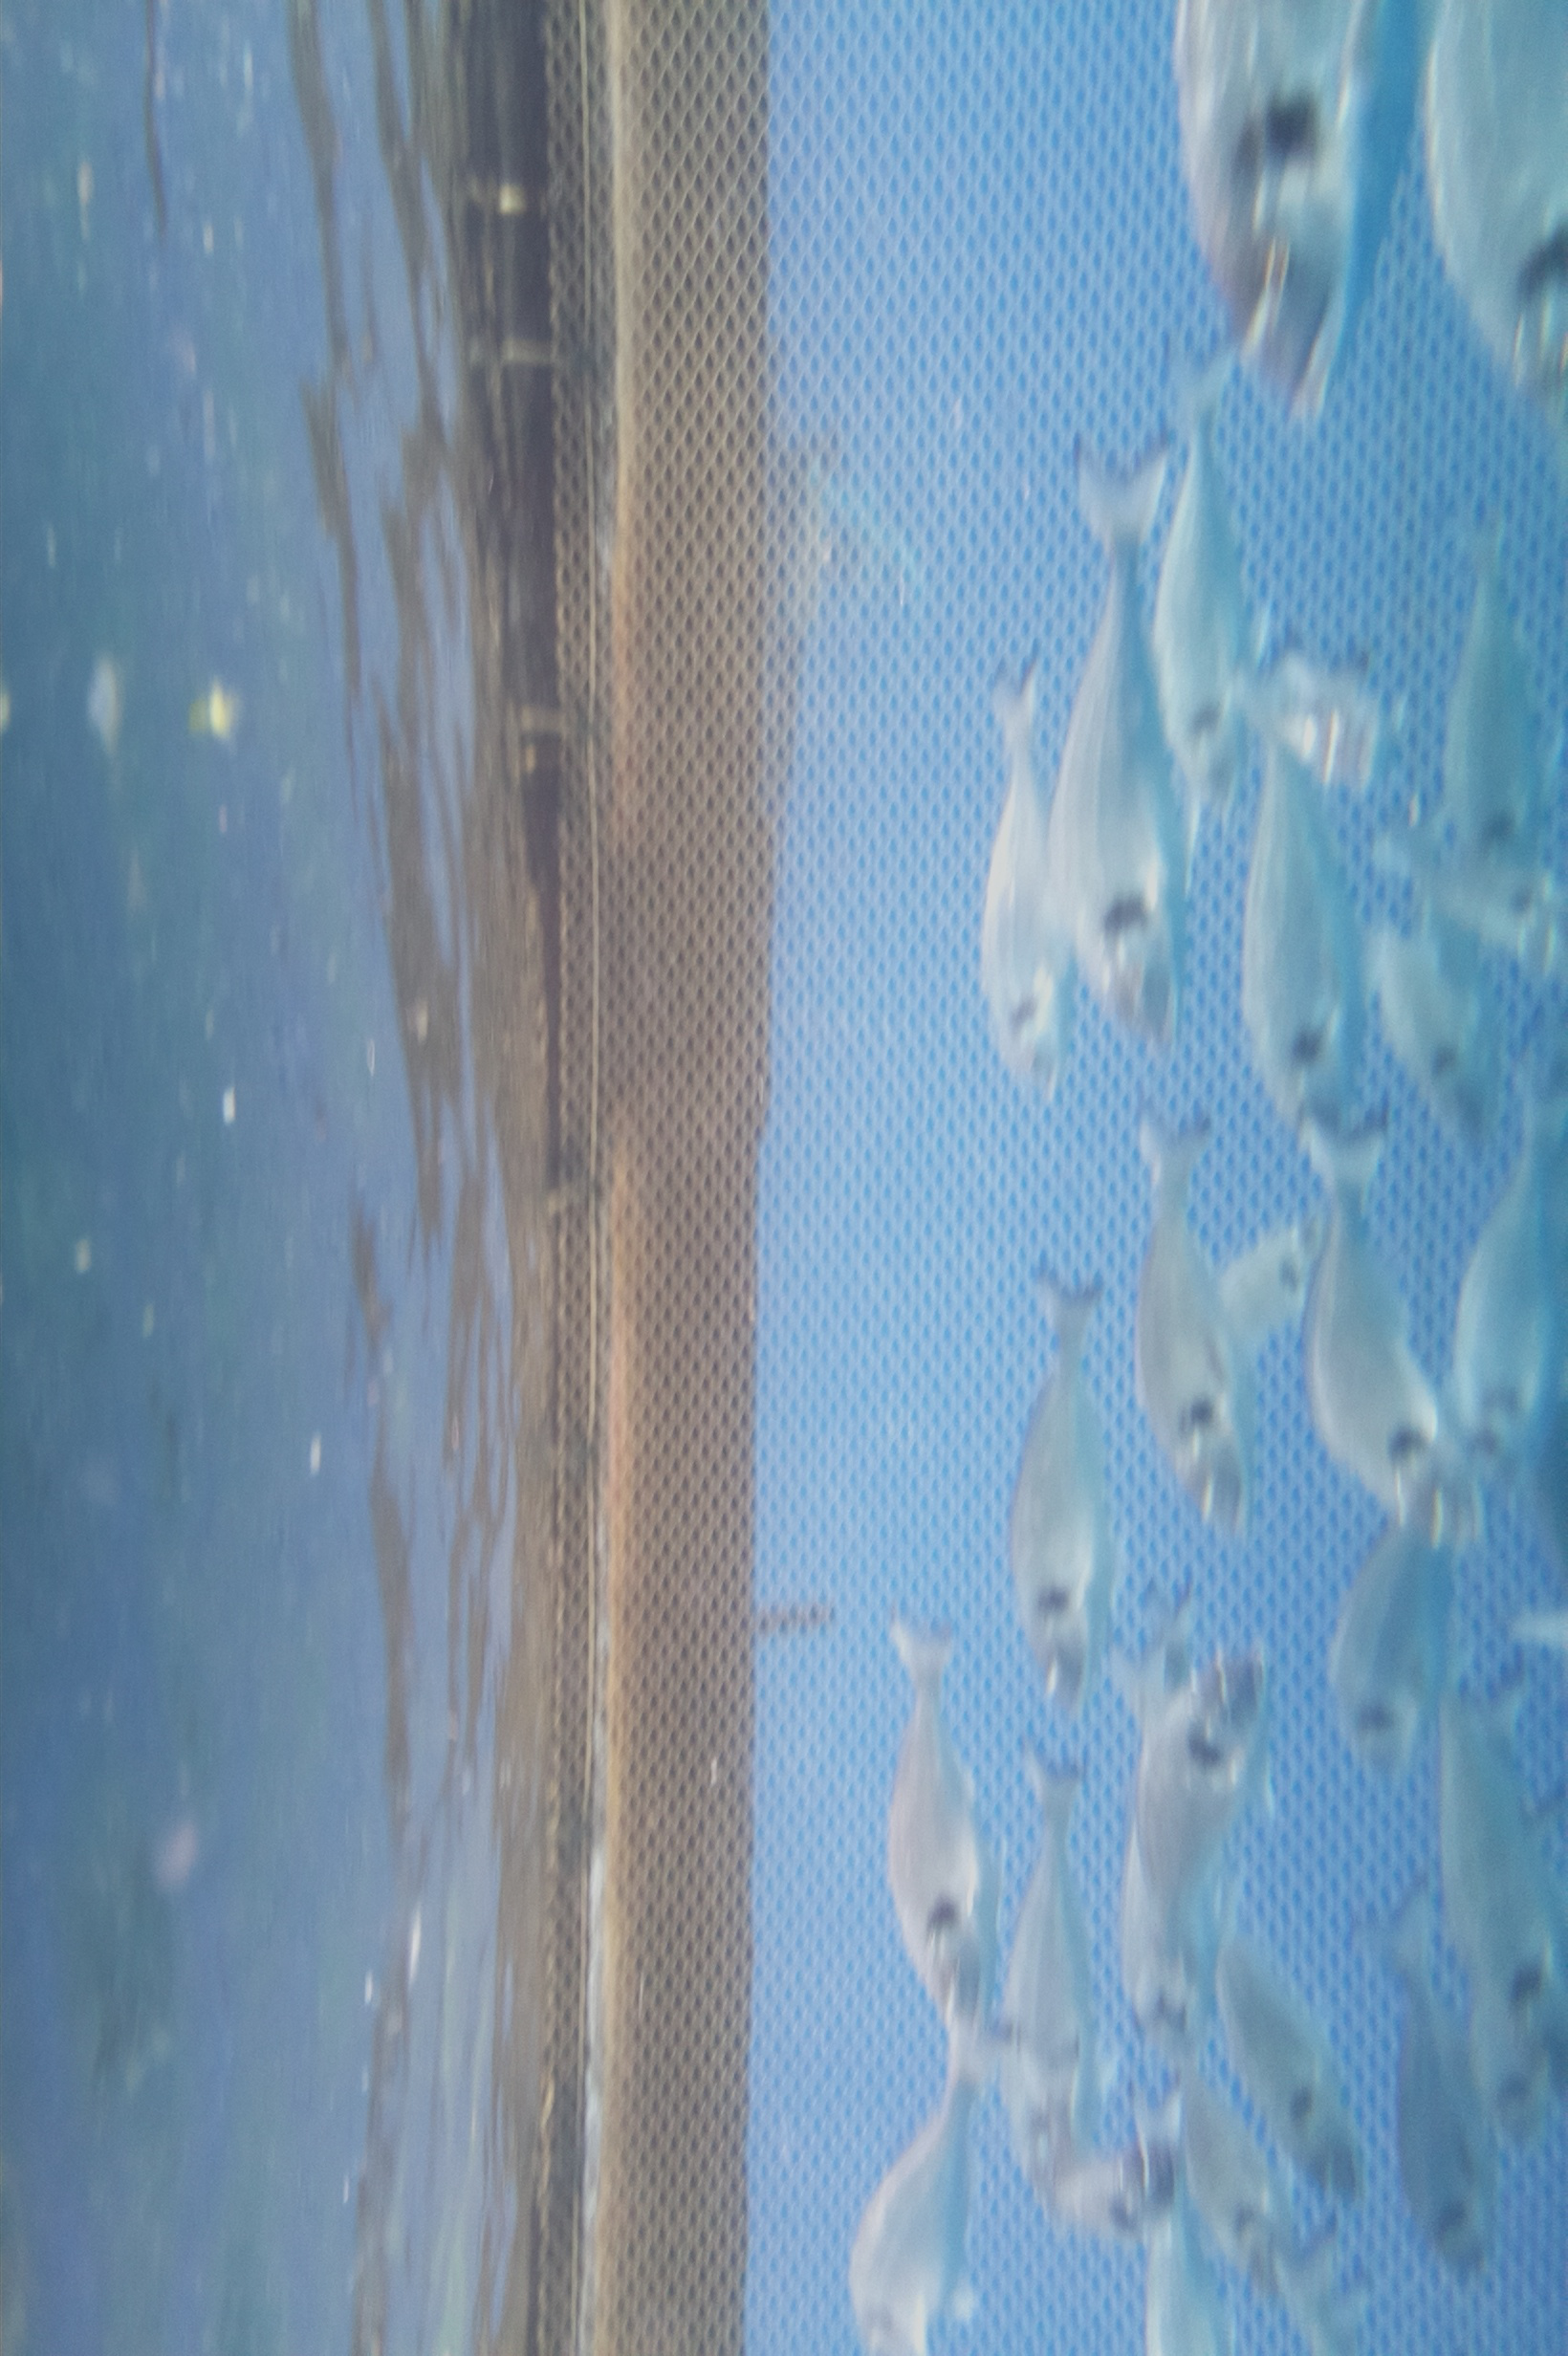

In [25]:
Image.open(f2)